# Automatic Short Answer Scoring — Mohler Dataset
### Pipeline: Preprocessing → Feature Engineering → Multi-Model Training → Evaluation

## 1. Imports

In [20]:
import pandas as pd
import numpy as np
import re
import string
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
print("All imports OK")


All imports OK


## 2. Load Dataset

In [21]:
file_path = 'Mohler_dataset_hf/Mohler_dataset_hf/data/raw-oe-00001.parquet'
df = pd.read_parquet(file_path)

# ---- Buat score rata-rata ----
df['score_avg'] = (df['score_grader_1'] + df['score_grader_2']) / 2

print(f"Total data: {len(df)}")
print(f"Score range: {df['score_avg'].min():.1f} – {df['score_avg'].max():.1f}")
print(f"Score distribution:\n{df['score_avg'].describe().round(3)}")
df.head()


Total data: 2273
Score range: 0.0 – 10.0
Score distribution:
count    2273.000
mean        5.167
std         2.313
min         0.000
25%         4.000
50%         5.000
75%         5.000
max        10.000
Name: score_avg, dtype: float64


,id,question,instructor_answer,student_answer,score_grader_1,score_grader_2,score_avg
0,E01.Q01.A00,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.0,4.0,3.5
1,E01.Q01.A01,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,5.0,5.0
2,E01.Q01.A02,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,3.0,5.0,4.0
3,E01.Q01.A03,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,5.0,5.0
4,E01.Q01.A04,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,3.0,3.0


## 3. Preprocessing
> **Fix**: angka TIDAK dihapus (banyak jawaban teknis pakai angka). Preprocessing lebih ringan agar makna tetap terjaga.

In [22]:
def preprocessing(text):
    if text is None or not isinstance(text, str):
        return ""
    text = text.strip()
    if len(text) == 0:
        return ""

    # lowercase
    text = text.lower()

    # normalize repeated chars (maaax -> max)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove URLs & emails
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # TIDAK menghapus angka — penting untuk jawaban teknis!
    # Hanya hapus karakter non-alphanumeric kecuali spasi
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['instructor_answer_clean'] = df['instructor_answer'].apply(preprocessing)
df['student_answer_clean']    = df['student_answer'].apply(preprocessing)

print("Sample hasil preprocessing:")
print("STUDENT :", df['student_answer_clean'].iloc[0])
print("INSTR   :", df['instructor_answer_clean'].iloc[0])


Sample hasil preprocessing:
STUDENT : high risk problems are address in the prototype program to make sure that the program is feasible a prototype may also be used to show a company that the software can be possibly programmed br br
INSTR   : to simulate the behaviour of portions of the desired software product


## 4. Train/Test Split (Stratified)
> **Fix**: pakai stratified split agar distribusi skor seimbang di train & test.

In [23]:
# Bin score untuk keperluan stratified split
df['score_bin'] = pd.cut(df['score_avg'], bins=5, labels=False)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['score_bin']
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Train score mean: {train_df['score_avg'].mean():.3f}")
print(f"Test  score mean: {test_df['score_avg'].mean():.3f}")


Train: 1818, Test: 455
Train score mean: 5.168
Test  score mean: 5.159


## 5. Sentence Embeddings
> Gunakan `all-mpnet-base-v2` — model terbaik untuk semantic similarity.

In [24]:
embedder = SentenceTransformer("all-mpnet-base-v2")

print("Encoding train set...")
train_student_emb    = embedder.encode(train_df['student_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)
train_instructor_emb = embedder.encode(train_df['instructor_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)

print("Encoding test set...")
test_student_emb    = embedder.encode(test_df['student_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)
test_instructor_emb = embedder.encode(test_df['instructor_answer_clean'].tolist(), show_progress_bar=True, batch_size=64)

print(f"Embedding shape: {train_student_emb.shape}")


Encoding train set...


Batches: 100%|██████████| 29/29 [01:10<00:00,  2.42s/it]


Encoding test set...


Batches: 100%|██████████| 8/8 [00:18<00:00,  2.36s/it]

Embedding shape: (1818, 768)


## 6. Feature Engineering
> **Perbaikan utama**: tambah banyak fitur linguistik & semantik untuk bantu model.

In [25]:
def get_word_overlap_features(text1, text2):
    """Hitung berbagai fitur overlap kata antara dua teks."""
    set1 = set(text1.split())
    set2 = set(text2.split())
    
    if not set1 or not set2:
        return 0.0, 0.0, 0.0
    
    intersection = set1 & set2
    union        = set1 | set2
    
    jaccard  = len(intersection) / len(union)
    recall   = len(intersection) / len(set2)   # berapa banyak keyword instruktur yang dicakup
    f1       = len(intersection) / len(set1) if set1 else 0.0  # precision dari sisi student
    
    return jaccard, recall, f1

def build_features(student_emb, instructor_emb, student_texts, instructor_texts):
    """Bangun feature matrix dari embedding + fitur linguistik."""
    n = len(student_texts)
    
    # 1. Cosine similarity (per-pair diagonal)
    cos_sim = cosine_similarity(student_emb, instructor_emb).diagonal().reshape(-1, 1)
    
    # 2. Embedding difference (menangkap dimensi mana student berbeda)
    emb_diff = np.abs(student_emb - instructor_emb)
    
    # 3. Embedding product (menangkap dimensi yang cocok)
    emb_prod = student_emb * instructor_emb
    
    # 4. Fitur panjang
    len_student = np.array([len(t.split()) for t in student_texts]).reshape(-1, 1)
    len_instr   = np.array([len(t.split()) for t in instructor_texts]).reshape(-1, 1)
    len_ratio   = len_student / (len_instr + 1)
    len_diff    = np.abs(len_student - len_instr)
    
    # 5. Overlap kata
    jaccard_list, recall_list, f1_list = [], [], []
    for s, i in zip(student_texts, instructor_texts):
        j, r, f = get_word_overlap_features(s, i)
        jaccard_list.append(j)
        recall_list.append(r)
        f1_list.append(f)
    
    word_feats = np.column_stack([jaccard_list, recall_list, f1_list])
    
    # 6. Euclidean distance antar embedding
    euc_dist = np.linalg.norm(student_emb - instructor_emb, axis=1).reshape(-1, 1)
    
    # Gabung semua fitur
    X = np.hstack([
        cos_sim,         # 1 fitur
        euc_dist,        # 1 fitur
        len_student,     # 1 fitur
        len_instr,       # 1 fitur
        len_ratio,       # 1 fitur
        len_diff,        # 1 fitur
        word_feats,      # 3 fitur (jaccard, recall, f1)
        emb_diff,        # 768 fitur
        emb_prod,        # 768 fitur
    ])
    return X

X_train = build_features(
    train_student_emb, train_instructor_emb,
    train_df['student_answer_clean'].tolist(),
    train_df['instructor_answer_clean'].tolist()
)
X_test = build_features(
    test_student_emb, test_instructor_emb,
    test_df['student_answer_clean'].tolist(),
    test_df['instructor_answer_clean'].tolist()
)

y_train = train_df['score_avg'].values
y_test  = test_df['score_avg'].values

print(f"Feature matrix shape: {X_train.shape}")


Feature matrix shape: (1818, 1545)


## 7. Training & Evaluasi Multi-Model

In [26]:
def evaluate(y_true, y_pred, model_name="Model"):
    """Hitung Pearson, MAE, QWK."""
    pearson, _ = pearsonr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    y_true_int = np.clip(np.rint(y_true).astype(int), 0, 5)
    y_pred_int = np.clip(np.rint(y_pred).astype(int), 0, 5)
    qwk = cohen_kappa_score(y_true_int, y_pred_int, weights="quadratic")
    
    print(f"[{model_name}]")
    print(f"  Pearson : {pearson:.4f}")
    print(f"  MAE     : {mae:.4f}")
    print(f"  QWK     : {qwk:.4f}")
    return {"model": model_name, "pearson": pearson, "mae": mae, "qwk": qwk}

results = []
predictions = {}


### 7a. Ridge Regression (baseline kuat, lebih baik dari LinearRegression untuk high-dim)

In [27]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
results.append(evaluate(y_test, pred_ridge, "Ridge Regression"))
predictions["Ridge"] = pred_ridge


[Ridge Regression]
  Pearson : 0.5728
  MAE     : 1.4712
  QWK     : 0.3690


### 7b. Gradient Boosting Regressor

In [28]:
gbr = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
results.append(evaluate(y_test, pred_gbr, "Gradient Boosting"))
predictions["GBR"] = pred_gbr


[Gradient Boosting]
  Pearson : 0.8532
  MAE     : 0.8404
  QWK     : 0.5675


### 7c. XGBoost Regressor

In [29]:
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
results.append(evaluate(y_test, pred_xgb, "XGBoost"))
predictions["XGBoost"] = pred_xgb


[XGBoost]
  Pearson : 0.8556
  MAE     : 0.8466
  QWK     : 0.5506


### 7d. LightGBM Regressor (Fix: evaluasi pakai pred LightGBM sendiri)

In [30]:
# FIX: dulu pakai `test_pred` dari model sebelumnya — sekarang pakai pred_lgb
lgbm = LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=-1, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbose=-1
)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)   # <-- WAJIB pakai ini untuk evaluasi LightGBM
results.append(evaluate(y_test, pred_lgbm, "LightGBM"))
predictions["LightGBM"] = pred_lgbm


[LightGBM]
  Pearson : 0.8406
  MAE     : 0.8534
  QWK     : 0.5488


### 7e. Ensemble: rata-rata prediksi model terbaik

In [31]:
# Ensemble sederhana: average dari GBR + XGB + LGBM
# pred_ensemble = (pred_gbr + pred_xgb + pred_lgbm) / 3
# results.append(evaluate(y_test, pred_ensemble, "Ensemble (GBR+XGB+LGBM)"))
# predictions["Ensemble"] = pred_ensemble


## 8. Ringkasan Hasil

In [32]:
results_df = pd.DataFrame(results).set_index("model")
results_df = results_df.sort_values("pearson", ascending=False)
print("\n=== RANKING MODEL ===")
print(results_df.round(4).to_string())



=== RANKING MODEL ===
                   pearson     mae     qwk
model                                     
XGBoost             0.8556  0.8466  0.5506
Gradient Boosting   0.8532  0.8404  0.5675
LightGBM            0.8406  0.8534  0.5488
Ridge Regression    0.5728  1.4712  0.3690


## 9. Visualisasi

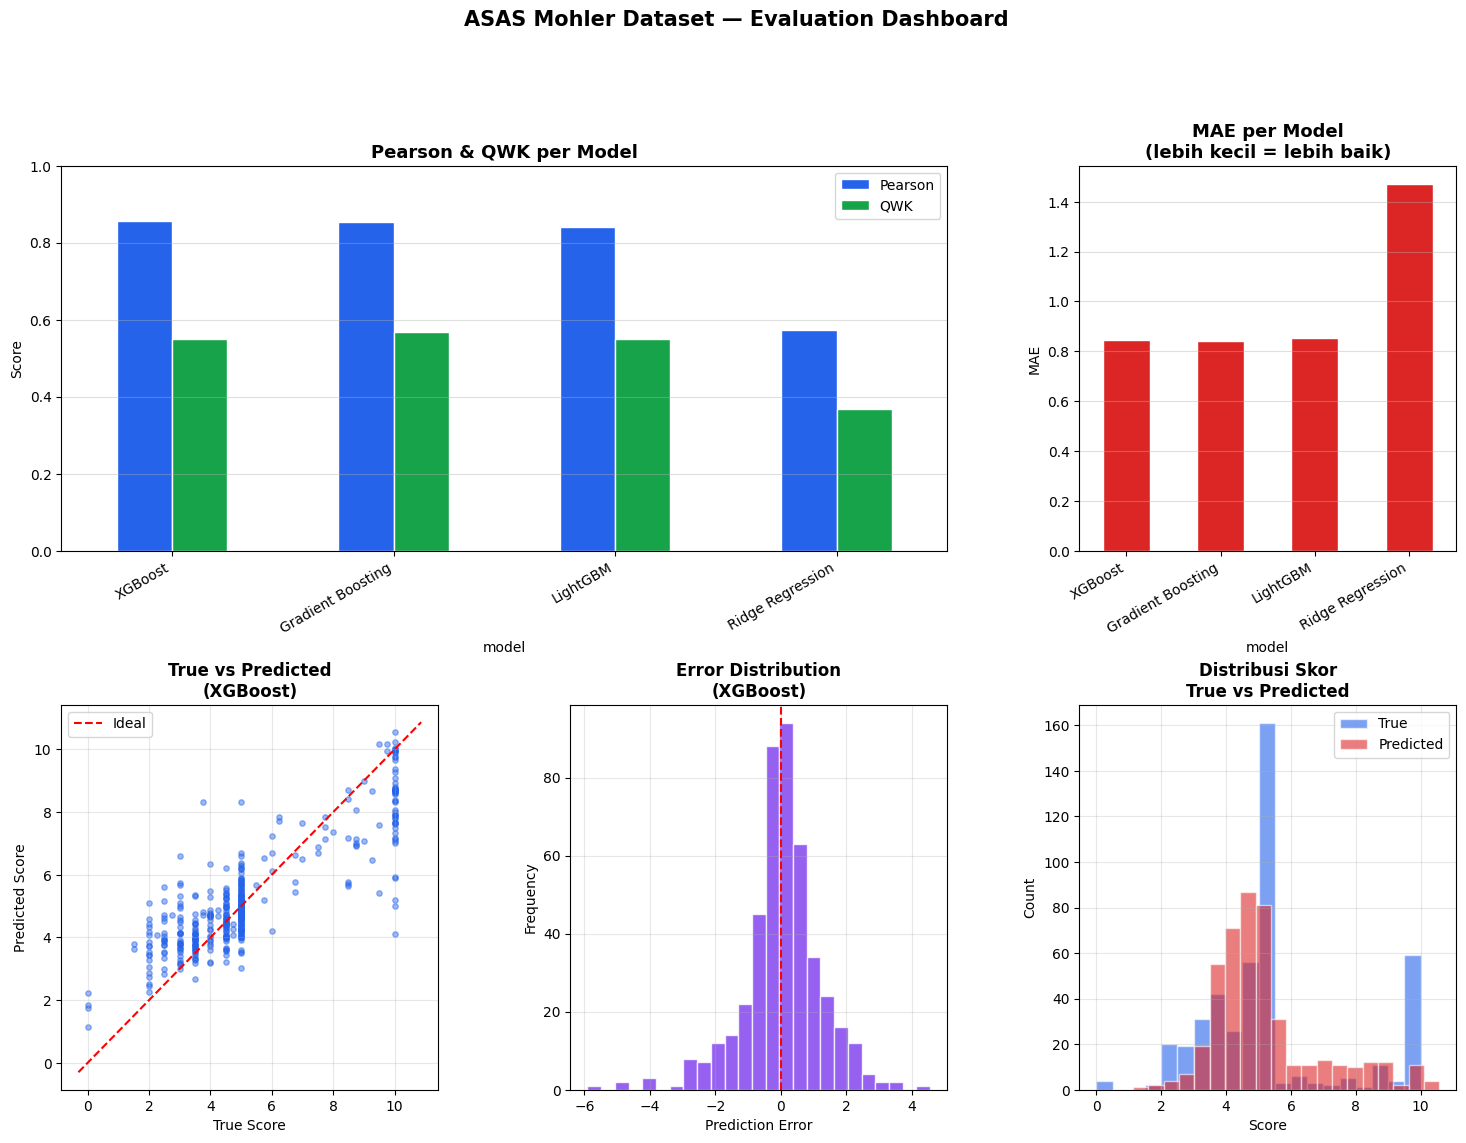

Plot saved: evaluation_dashboard.png


In [33]:
best_model_name = results_df.index[0]
pred_best = predictions[best_model_name]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ---- 1. Bar chart metrik per model ----
ax1 = fig.add_subplot(gs[0, :2])
results_df[['pearson', 'qwk']].plot(kind='bar', ax=ax1, color=['#2563EB', '#16A34A'], edgecolor='white')
ax1.set_title('Pearson & QWK per Model', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xticklabels(results_df.index, rotation=30, ha='right')
ax1.set_ylim(0, 1)
ax1.legend(['Pearson', 'QWK'])
ax1.grid(axis='y', alpha=0.4)

# ---- 2. MAE per model ----
ax2 = fig.add_subplot(gs[0, 2])
results_df['mae'].plot(kind='bar', ax=ax2, color='#DC2626', edgecolor='white')
ax2.set_title('MAE per Model\n(lebih kecil = lebih baik)', fontsize=13, fontweight='bold')
ax2.set_ylabel('MAE')
ax2.set_xticklabels(results_df.index, rotation=30, ha='right')
ax2.grid(axis='y', alpha=0.4)

# ---- 3. Scatter: True vs Predicted (best model) ----
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_test, pred_best, alpha=0.45, s=15, color='#2563EB')
lims = [min(y_test.min(), pred_best.min()) - 0.3, max(y_test.max(), pred_best.max()) + 0.3]
ax3.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
ax3.set_xlabel('True Score')
ax3.set_ylabel('Predicted Score')
ax3.set_title(f'True vs Predicted\n({best_model_name})', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# ---- 4. Error distribution (best model) ----
ax4 = fig.add_subplot(gs[1, 1])
errors = pred_best - y_test
ax4.hist(errors, bins=25, color='#7C3AED', edgecolor='white', alpha=0.8)
ax4.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Prediction Error')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Error Distribution\n({best_model_name})', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# ---- 5. Score distribution: true vs predicted ----
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(y_test,    bins=20, alpha=0.6, color='#2563EB', label='True', edgecolor='white')
ax5.hist(pred_best, bins=20, alpha=0.6, color='#DC2626', label='Predicted', edgecolor='white')
ax5.set_xlabel('Score')
ax5.set_ylabel('Count')
ax5.set_title('Distribusi Skor\nTrue vs Predicted', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle('ASAS Mohler Dataset — Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: evaluation_dashboard.png")


## 10. Contoh Prediksi vs Ground Truth

In [34]:
test_df['pred_best'] = pred_best
sample = test_df[['student_answer', 'instructor_answer', 'score_avg', 'pred_best']].sample(10, random_state=7)
sample['error'] = (sample['pred_best'] - sample['score_avg']).round(3)
sample = sample.rename(columns={
    'student_answer': 'Student Answer',
    'instructor_answer': 'Reference Answer',
    'score_avg': 'True Score',
    'pred_best': 'Predicted Score',
})
sample['Predicted Score'] = sample['Predicted Score'].round(3)
pd.set_option('display.max_colwidth', 60)
sample


,Student Answer,Reference Answer,True Score,Predicted Score,error
375,prototype states all functions in that class before comp...,"A function prototype includes the function signature, i....",3.5,3.975,0.475
163,push,push,5.0,5.003,0.003
206,a queue can be implemented in a list by keeping track of...,Keep the rear of the queue pointing to the tail of the l...,4.5,3.982,-0.518
294,"data members are permanent attributes of the class, loca...",Data members can be accessed from any member functions i...,4.0,4.684,0.684
129,overloaded function simply invovles haing a method with ...,Based on the function signature. When an overloaded func...,3.0,5.663,2.663
452,It starts with the second element and checks it to see i...,"Taking one array element at a time, from left to right, ...",5.0,5.743,0.743
242,it depends on the install search tree then from there fo...,The height of the tree.,3.0,6.608,3.608
164,"Gives access to the caller data directly, also it allows...",It avoids making copies of large data structures when ca...,3.5,4.091,0.591
395,Data members are variables that are declared inside the ...,Data members can be accessed from any member functions i...,4.5,4.404,-0.096
369,in a circular linked list the the last item points to th...,The last element in a circular linked list points to the...,5.0,5.078,0.078
